In [1]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import pandas as pd
import numpy as np
import gc
from IPython.display import JSON
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from functools import partial
from src.jsonl_dataset import JsonLDataset
from transformers import AutoTokenizer, TrainingArguments, EvalPrediction
from adapters import AutoAdapterModel, AdapterTrainer

In [2]:
def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# Datasets Initialization

In [3]:
path = kagglehub.dataset_download("Cornell-University/arxiv/versions/272")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
master_ds = JsonLDataset(ds_path)
augmented_ds = JsonLDataset("resources/augmented_index.jsonl")

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.
Indexing dataset at resources/augmented_index.jsonl... (this may take a minute)
Indexed 2951540 entries.


In [4]:
def load_indices_from_jsonl(file_path, flatten=False, shuffle=False, seed=None):
    data_list = []
    
    with open(file_path, 'r') as f:
        data_list = [json.loads(line) for line in f]
            
    arr = np.array(data_list)

    if flatten:
        arr = arr.flatten()

    if shuffle:
        rng = np.random.default_rng(seed) 
        rng.shuffle(arr)

    return np.unique(arr)

In [5]:
train_indices = load_indices_from_jsonl("resources/train_indicies_parent_categories.jsonl", flatten=True, shuffle=True, seed=42)
test_indices = load_indices_from_jsonl("resources/test_indices_parent_categories.jsonl", flatten=True, shuffle=True, seed=42)

In [6]:
class IndexBasedDataset(Dataset):
    """
    The indices in the dataset are engineered based on the specific task. 
    They are precomputed, and stored in the /resources folder.
    The indices ensure the classes distribution match the training task requirements.
    For details on how the indices are constructed - check data_selection.ipynb

    The /resources folder should have 4 indices in total :
    - train and test for the parent categories classification task
    - train and test for the sub categories classification task
    """
    
    def __init__(self, master_dataset, augmented_datset, indices):
        self.master_dataset = master_dataset
        self.augmented_datset = augmented_datset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        master_idx = self.indices[idx]
        return {
            "master_idx": master_idx,
            "title": self.master_dataset[master_idx]["title"],
            "abstract": self.master_dataset[master_idx]["abstract"],
            "raw_categories": self.master_dataset[master_idx]["categories"],
            "parent_categories": self.augmented_datset[master_idx][2],
            "remapped_categories": self.augmented_datset[master_idx][3]
        }

In [7]:
train_ds = IndexBasedDataset(master_ds, augmented_ds, train_indices)
test_ds = IndexBasedDataset(master_ds, augmented_ds, test_indices)

In [8]:
pipeline_test = True
if pipeline_test:
    sub_train_size = 1000
    sub_test_size = 200
    train_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(train_indices, 1000))
    test_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(train_indices, 200))
else:
    train_ds = IndexBasedDataset(master_ds, augmented_ds, train_indices)
    test_ds = IndexBasedDataset(master_ds, augmented_ds, test_indices)

# Train Pipeline

In [71]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Define your Fixed Taxonomy
TARGET_PARENT_CLASSES = [
    'Physics', 
    'Mathematics', 
    'Computer Science', 
    'Quantitative Biology', 
    'Statistics', 
    'Quantitative Finance', 
    'Economics', 
    'Electrical Engineering and Systems Science'
]

# 2. Initialize Binarizer (Maps lists of strings -> One-Hot Vectors)
# We fit it once globally so the order is consistent.
mlb = MultiLabelBinarizer(classes=TARGET_PARENT_CLASSES)
mlb.fit([TARGET_PARENT_CLASSES])  # Just to initialize the classes

MultiLabelBinarizer(classes=['Physics', 'Mathematics', 'Computer Science',
                             'Quantitative Biology', 'Statistics',
                             'Quantitative Finance', 'Economics',
                             'Electrical Engineering and Systems Science'])

In [10]:
class SpecterCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        """
        batch: A list of dicts from your IndexBasedDataset
        """
        # A. Extract Text
        # Specter2 Format: Title + [SEP] + Abstract
        texts = [
            f"{item['title']}{self.tokenizer.sep_token}{item.get('abstract', '')}" 
            for item in batch
        ]

        # B. Tokenize
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        # C. Process Labels (Multi-Hot Encoding)
        # Extract the list of strings from each item
        raw_labels = [item['parent_categories'] for item in batch]
        
        # Transform [['Physics'], ['Math', 'CS']] -> [[1,0...], [0,1,1...]]
        # Note: We must convert to FloatTensor for BCEWithLogitsLoss (Multi-label loss)
        labels_encoded = mlb.transform(raw_labels)
        inputs['labels'] = torch.tensor(labels_encoded, dtype=torch.float32)

        return inputs

In [75]:
import torch
import gc
from dataclasses import dataclass
from transformers import AutoTokenizer, TrainingArguments, EvalPrediction
from adapters import AutoAdapterModel, AdapterTrainer, Stack  # <--- Imported Stack
from sklearn.metrics import f1_score

@dataclass
class TrainingConfig:
    learning_rate: float = 1e-4
    num_train_epochs: int = 3
    train_batch_size: int = 8
    eval_batch_size: int = 8
    logging_steps: int = 50
    save_strategy: str = "epoch"
    eval_strategy: str = "epoch"

def train_pipeline(
    train_dataset, 
    eval_dataset=None, 
    hyperparams: TrainingConfig = TrainingConfig(),
    output_dir: str = "./checkpoints",
    adapter_save_path: str = "./final_multilabel_adapter",
    device: str = "cuda",
    adapter_name: str = None,
    num_target_classes: int = -1
):
    print(f"Using device: {device}")

    # --- B. Load Model ---
    model_name = "allenai/specter2_base"
    model = AutoAdapterModel.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model.to(device) # Move to GPU explicitly
    
    # 1. Load (frozen base)
    model.load_adapter("allenai/specter2_classification", source="hf", load_as=adapter_name)

    # 2. Add Head
    model.add_classification_head(
        adapter_name,
        num_labels=num_target_classes,
        multilabel=True  
    )
    
    # 3. Activation (The Fix)
    model.train_adapter(adapter_name)           # Enable gradients
    model.set_active_adapters(adapter_name)
    model.active_head = adapter_name            # Force prediction head

    # --- D. Metrics ---
    def compute_metrics(p: EvalPrediction):
        probs = torch.sigmoid(torch.tensor(p.predictions)).numpy()
        preds = (probs > 0.5).astype(int)
        labels = p.label_ids
        return {
            "f1_micro": f1_score(labels, preds, average="micro"),
            "f1_macro": f1_score(labels, preds, average="macro"),
        }

    # --- E. Trainer ---
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=hyperparams.learning_rate,
        num_train_epochs=hyperparams.num_train_epochs,
        per_device_train_batch_size=hyperparams.train_batch_size,
        per_device_eval_batch_size=hyperparams.eval_batch_size,
        logging_steps=hyperparams.logging_steps,
        eval_strategy=hyperparams.eval_strategy if eval_dataset else "no",
        save_strategy=hyperparams.save_strategy,
        remove_unused_columns=False,
        report_to="none"
    )

    trainer = AdapterTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        data_collator=SpecterCollator(tokenizer), 
        compute_metrics=compute_metrics,
    )

    # --- Safety Wrapper ---
    try:
        print("🚀 Starting training...")
        trainer.train()
        
        print(f"✅ Training complete. Saving to {adapter_save_path}...")
        model.save_adapter(adapter_save_path, adapter_name)
        return model

    except KeyboardInterrupt:
        print("\n🛑 Interrupted!")
        del trainer, training_args
        gc.collect()
        torch.cuda.empty_cache()
        raise

    except Exception as e:
        del trainer
        gc.collect()
        torch.cuda.empty_cache()
        raise e

In [78]:
config = TrainingConfig(
    learning_rate=5e-4, 
    num_train_epochs=3, 
    train_batch_size=20,
    logging_steps=10
)

trained_model = train_pipeline(
    train_dataset=train_ds, 
    eval_dataset=test_ds, 
    hyperparams=config,
    output_dir="./checkpoints",
    adapter_save_path="./resources/parent_categories_adapter",
    adapter_name="arxiv_parent_categories_classifier",
    num_target_classes=len(TARGET_PARENT_CLASSES)
)

Using device: cuda


KeyboardInterrupt: 

In [14]:
clear_gpu_memory()

Allocated: 442.67 MB
Reserved:  506.00 MB


In [15]:
def classify_sample(
    model, 
    tokenizer, 
    text_input: str, 
    target_classes: list, 
    device: str = "cuda", 
    threshold: float = 0.5
):
    """
    Classifies a single text sample using the loaded Adapter model.
    """
    # 1. Prepare Model
    model.eval()  # Disable dropout/batchnorm for inference
    model.to(device)
    
    # 2. Tokenize
    # Specter 2 handles inputs up to 512 tokens. 
    # If passing Title + Abstract, ensure they are concatenated properly before this.
    inputs = tokenizer(
        text_input,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    
    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 4. Process Logits
    # The model output depends on the head configuration. 
    # For AutoAdapterModel with a head, outputs.logits contains the classification scores.
    logits = outputs.logits
    
    # Apply Sigmoid because we defined multilabel=True (independent probabilities)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    
    # 5. Decode to Labels
    # Get indices where probability is higher than threshold
    predicted_indices = (probs > threshold).nonzero()[0]
    
    # Map indices to class names
    predicted_labels = [target_classes[i] for i in predicted_indices]
    
    # Create a detailed result with confidence scores
    results = [
        {"label": target_classes[i], "score": float(probs[i])} 
        for i in predicted_indices
    ]
    
    # Sort by confidence (highest first)
    results.sort(key=lambda x: x["score"], reverse=True)
    
    return results

In [73]:
rand_idx = random.randint(0, len(test_ds))

tokenizer = AutoTokenizer.from_pretrained(model_name)
sample = test_ds[rand_idx]
inp = f"{sample['title']}{tokenizer.sep_token}{sample.get('abstract', '')}"

print(classify_sample(trained_model, tokenizer, inp, TARGET_PARENT_CLASSES))
JSON(sample)

[{'label': 'Computer Science', 'score': 0.9779873490333557}, {'label': 'Statistics', 'score': 0.9278832077980042}]


<IPython.core.display.JSON object>

# Check how often the NR of tokens generated by the tokenizer exceed the 512 threshold

In [81]:
num_tokens = []
for sample in train_ds:
    inputs = tokenizer(
        f"{sample['title']}{tokenizer.sep_token}{sample.get('abstract', '')}",
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    
    num_tokens.append(inputs["attention_mask"].sum().item())

In [100]:
def plot_histogram(data, bins=10, title="Histogram of the tokencount in the abstract", xlabel="Values", color='skyblue'):
    plt.figure(figsize=(10, 6))  # Set figure size
    
    # Plot the histogram
    # edgecolor='black' adds a border to each bar for better visibility
    plt.hist(data, bins=bins, color=color, edgecolor='black', alpha=0.7)
    
    # Add labels and title
    plt.title(title + f" of {len(data)} samples.")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    
    # Add a grid behind the bars
    plt.grid(axis='y', alpha=0.5)
    
    # Display the plot
    plt.show()

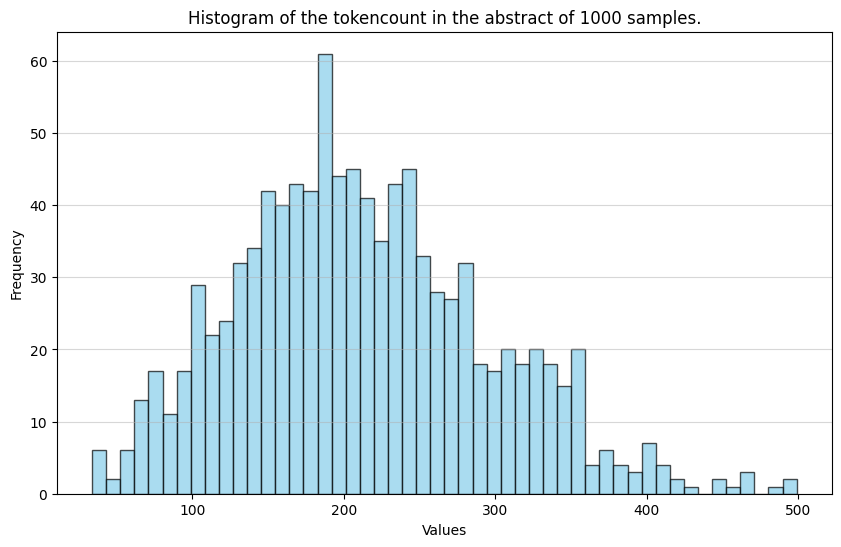

In [102]:
plot_histogram(num_tokens, bins=50)

In [92]:
np.array(np.array(num_tokens) == 512).sum()

0

In [61]:
model.active_adapters.first()

'arxiv_parent_categories_classifier'

In [69]:
import warnings

# This tells Python: "If you see this specific warning message, crash immediately."
warnings.filterwarnings("error", message="There are adapters available but none are activated for the forward pass.")

In [81]:
active_adapters = getattr(model, "active_adapters", None)
if not active_adapters:
    if model.has_adapters():
        logger.warning("There are adapters available but none are activated for the forward pass.")
else:
    print("Hui")

Hui


In [79]:
active_adapters

Stack[arxiv_parent_categories_classifier]

In [72]:
model.active_adapters

Stack[arxiv_parent_categories_classifier]

In [71]:
model.has_adapters()

True